# Compact-reference reconstruction

In [ ]:
%matplotlib inline
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT/'src'/'lss').exists():
    ROOT = ROOT.parent
if str(ROOT/'src') not in sys.path:
    sys.path.insert(0, str(ROOT/'src'))

from lss.plotting import apply_editorial_style, DATASET_COLORS, PAPER_COLORS
apply_editorial_style()
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[PAPER_COLORS[k] for k in ('blue','red','green','purple','orange','sky','gold','slate')])
BASE = ROOT / 'notebooks/results/compact_lj_reconstruction'
AUDIT = ROOT / 'notebooks/results/compact_lj_motion_audit'
LABELS = {'reid':'Reid', 'depablo_low_temp':'dePablo low-T', 'lj_noisy':'Noisy LJ', 'depablo_mixed_temp':'Mixed-T transfer'}


## Observed training trajectories

,Source,Valid / total,Displacement RMS,Affine residual RMS,"Increment cosine, lag 10"
0,dePablo low-T,10 / 10,0.006627,0.001563,0.999306
1,Noisy LJ,10 / 10,0.006741,0.002847,0.995366
2,Reid,10 / 10,0.006855,0.002111,0.999082


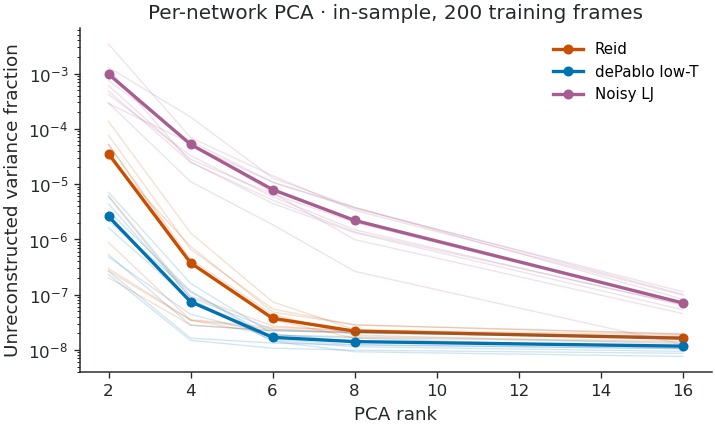

In [ ]:
audit = json.loads((AUDIT / 'audit.json').read_text())
rows = json.loads((AUDIT / 'trajectory_rows.json').read_text())
summary = pd.DataFrame([{'Source':LABELS[s], 'Valid / total':f"{v['trajectories_valid']} / {v['trajectories_total']}",
    'Displacement RMS':v['displacement_rms_from_initial_mean']['mean'],
    'Affine residual RMS':v['affine_residual_rms_mean']['mean'],
    'Increment cosine, lag 10':v['increment_cosine_by_lag']['10']['mean']}
    for s,v in audit['summary'].items()])
display(summary)
fig, ax = plt.subplots(figsize=(6.2,3.8))
for source in ('reid','depablo_low_temp','lj_noisy'):
    group = [r for r in rows if r['source']==source]
    ranks = [2,4,6,8,16]
    values = np.array([[r['pca_centered_train_reconstruction_error_fraction'][str(k)] for k in ranks] for r in group])
    for y in values: ax.plot(ranks,y,color=DATASET_COLORS[source],alpha=.18,lw=.8)
    ax.plot(ranks,values.mean(0),'o-',color=DATASET_COLORS[source],label=LABELS[source])
ax.set(xlabel='PCA rank',ylabel='Unreconstructed variance fraction',yscale='log',title='Per-network PCA · in-sample, 200 training frames')
ax.legend(frameon=False);fig.tight_layout();plt.show()


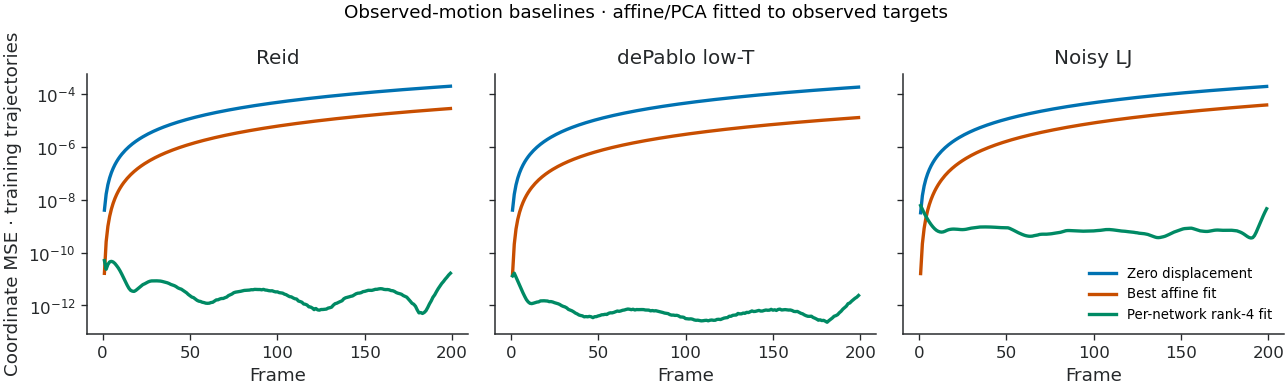

In [ ]:
frame_audit = pd.read_json(AUDIT/'frame_rows_v1.json')
metrics = {'zero_motion_mse':'Zero displacement','affine_x0_to_xt_mse':'Best affine fit','pca_in_sample_rank4_mse':'Per-network rank-4 fit'}
fig, axes = plt.subplots(1,3,figsize=(11,3.4),sharex=True,sharey=True)
for ax,source in zip(axes,('reid','depablo_low_temp','lj_noisy')):
    g = frame_audit[frame_audit.source==source].groupby('frame')[list(metrics)].mean()
    for metric,label in metrics.items(): ax.plot(g.index[1:],g[metric].iloc[1:],label=label)
    ax.set(title=LABELS[source],xlabel='Frame',yscale='log')
axes[0].set_ylabel('Coordinate MSE · training trajectories')
axes[-1].legend(frameon=False,fontsize=8)
fig.suptitle('Observed-motion baselines · affine/PCA fitted to observed targets',fontsize=11)
fig.tight_layout();plt.show()


## Reconstruction runs

,Variant,Seed,Version,Status,Job
0,ljonly_r16_d4,123,code_v2,completed,4672478.zeus-master
1,ljonly_r16_d4,2026,code_v2,completed,4672481.zeus-master
2,ljonly_r16_d4,3456456,code_v2,completed,4672477.zeus-master
3,ljonly_r16_d4,456,code_v2,completed,4672479.zeus-master
4,ljonly_r16_d4,786,code_v2,completed,4672480.zeus-master
...,...,...,...,...,...
65,spatial_r16_d8,123,code_v1,no terminal result,4673348.zeus-master
66,spatial_r16_d8,2026,code_v1,no terminal result,4673351.zeus-master
67,spatial_r16_d8,3456456,code_v1,no terminal result,4673347.zeus-master
68,spatial_r16_d8,456,code_v1,no terminal result,4673349.zeus-master


,version,variant,source,frame,coordinate_mse,valid,total,seeds
10,code_v2,ljonly_r16_d4,lj_noisy,199,0.000041,100,100,5
21,code_v2,ljonly_r16_d8,lj_noisy,199,0.000043,100,100,5
32,code_v2,mp2_r16_d4,depablo_low_temp,199,0.000010,100,100,5
43,code_v2,mp2_r16_d4,depablo_mixed_temp,199,0.000032,100,100,5
54,code_v2,mp2_r16_d4,lj_noisy,199,0.000038,100,100,5
65,code_v2,mp2_r16_d4,reid,199,0.000029,100,100,5
76,code_v2,mp2_r16_d8,depablo_low_temp,199,0.000010,100,100,5
87,code_v2,mp2_r16_d8,depablo_mixed_temp,199,0.000033,100,100,5
98,code_v2,mp2_r16_d8,lj_noisy,199,0.000038,100,100,5
109,code_v2,mp2_r16_d8,reid,199,0.000029,100,100,5


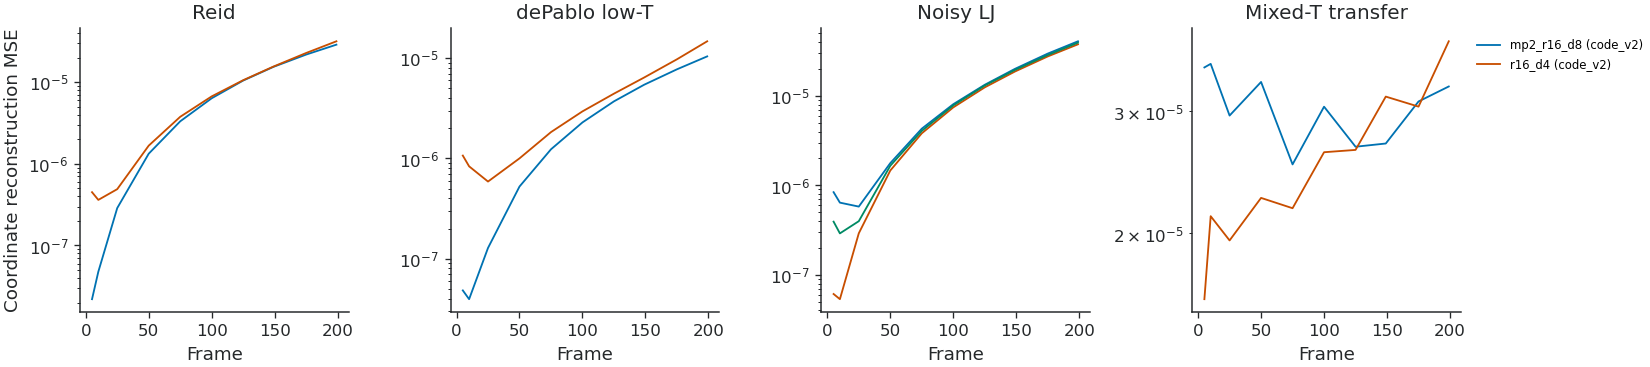

In [ ]:
status = []
results = []
folders = list(BASE.glob('*_s*_code_v*')) + list((ROOT/'notebooks/results/compact_lj_spatial_decoder').glob('*_s*_code_v*'))
for folder in sorted(folders):
    if folder.name.endswith('_smoke') or not folder.is_dir(): continue
    recipe_path = folder/'recipe.json'
    if not recipe_path.exists(): continue
    recipe = json.loads(recipe_path.read_text())
    state = 'completed' if (folder/'completed.json').exists() else 'failed' if (folder/'failed.json').exists() else 'no terminal result'
    status.append({'Variant':recipe['variant'],'Seed':recipe['seed'],'Version':recipe['code_version'],'Status':state,'Job':recipe['job_id']})
    if state == 'completed':
        f = pd.read_csv(folder/'source_frame_rows.csv')
        f['variant']=recipe['variant']; f['seed']=recipe['seed']; f['version']=recipe['code_version'];results.append(f)
display(pd.DataFrame(status))
if results:
    result = pd.concat(results,ignore_index=True)
    val = result[result.split.isin(['validation','mixed_transfer'])]
    table = val.groupby(['version','variant','source','frame']).agg(coordinate_mse=('coordinate_mse','mean'),valid=('valid','sum'),total=('total','sum'),seeds=('seed','nunique')).reset_index()
    display(table[table.frame==199])
    fig, axes = plt.subplots(1,4,figsize=(14,3.3),sharex=True)
    for ax, source in zip(axes, LABELS):
        plot_variants = ['r16_d4','mp2_r16_d8','ljonly_r16_d4','spatial_r16_d2','spatial_r16_d4','spatial_r16_d8']
        for (version,variant),group in table[(table.source==source)&(table.frame>0)&table.variant.isin(plot_variants)].groupby(['version','variant']):
            ax.plot(group.frame,group.coordinate_mse,label=f'{variant} ({version})',lw=1.1)
        ax.set(title=LABELS[source],xlabel='Frame',yscale='log')
    axes[0].set_ylabel('Coordinate reconstruction MSE')
    axes[-1].legend(frameon=False,fontsize=7,bbox_to_anchor=(1.02,1),loc='upper left')
    fig.tight_layout();plt.show()


## Frozen-decoder code fitting

,variant,frame,encoded_mse,optimized_mse,affine_fit_mse,pca4_fit_mse,evaluations
0,ljonly_r16_d4,25,5.636184e-07,2.668673e-07,2.792349e-07,5.190170e-10,9
1,ljonly_r16_d4,100,8.610523e-06,7.475085e-06,7.630882e-06,6.076722e-10,9
2,ljonly_r16_d4,199,3.067091e-05,2.789504e-05,2.682967e-05,2.319963e-09,9
3,r16_d4,25,3.210976e-07,2.559235e-07,2.792349e-07,5.190170e-10,9
4,r16_d4,100,8.032992e-06,7.213731e-06,7.630882e-06,6.076722e-10,9
5,r16_d4,199,2.909200e-05,2.622258e-05,2.682967e-05,2.319963e-09,9


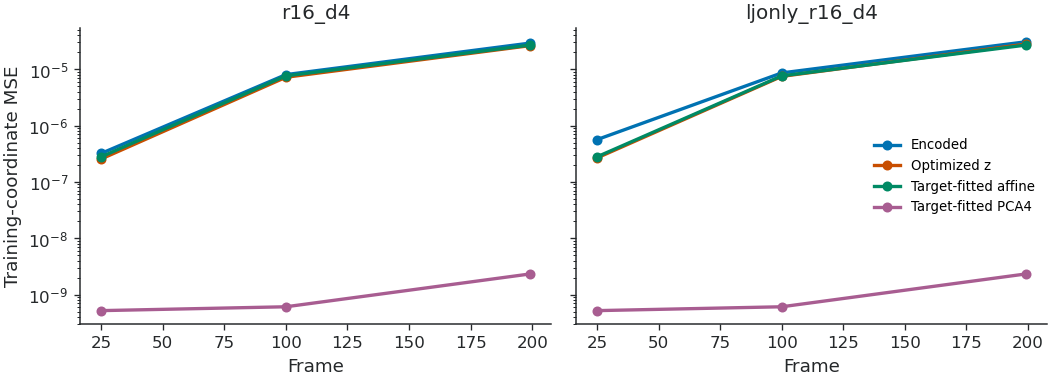

In [ ]:
fitted = pd.read_csv(ROOT/'notebooks/results/compact_lj_fitted_codes/matched_optimistic_baselines.csv')
display(fitted.groupby(['variant','frame']).agg(encoded_mse=('encoded','mean'),optimized_mse=('best','mean'),affine_fit_mse=('affine_x0_to_xt_mse','mean'),pca4_fit_mse=('pca_in_sample_rank4_mse','mean'),evaluations=('seed','size')).reset_index())
fig, axes = plt.subplots(1,2,figsize=(9,3.4),sharey=True)
for ax,variant in zip(axes,['r16_d4','ljonly_r16_d4']):
    g=fitted[fitted.variant==variant].groupby('frame')[['encoded','best','affine_x0_to_xt_mse','pca_in_sample_rank4_mse']].mean()
    for col,label in [('encoded','Encoded'),('best','Optimized z'),('affine_x0_to_xt_mse','Target-fitted affine'),('pca_in_sample_rank4_mse','Target-fitted PCA4')]:
        ax.plot(g.index,g[col],'o-',label=label)
    ax.set(title=variant,xlabel='Frame',yscale='log')
axes[0].set_ylabel('Training-coordinate MSE');axes[1].legend(fontsize=8)
fig.tight_layout();plt.show()
